1. LOGISTIC REGRESSION

A. Loads merged data, separates features/target, and creates train–test split

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

india_df = pd.read_csv("../data/processed/india_cleaned_aligned.csv")
us_df = pd.read_csv("../data/processed/us_cleaned_aligned.csv")

centralized_df = pd.concat([india_df, us_df], axis=0).reset_index(drop=True)

X = centralized_df.drop(columns=["Diabetes_binary"])
y = centralized_df["Diabetes_binary"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


B. Imports required class and defines the Logistic Regression

In [2]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

In [3]:
lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


C. Generates class predictions and probability scores for evaluation

In [4]:
y_pred_lr = lr_model.predict(X_test)
y_proba_lr = lr_model.predict_proba(X_test)[:, 1]

D. Evaluates baseline performance using accuracy and detailed class-wise metrics

In [5]:
from sklearn.metrics import accuracy_score, classification_report

lr_accuracy = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", lr_accuracy)

print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.696920552176851
              precision    recall  f1-score   support

           0       0.94      0.69      0.79     44185
           1       0.29      0.74      0.42      7610

    accuracy                           0.70     51795
   macro avg       0.62      0.72      0.61     51795
weighted avg       0.84      0.70      0.74     51795



E. Shows how many predictions were correct and wrong for each class

In [6]:
from sklearn.metrics import confusion_matrix

cm_lr = confusion_matrix(y_test, y_pred_lr)
print(cm_lr)

[[30429 13756]
 [ 1942  5668]]


F. Calculates how well the model separates diabetic vs non-diabetic cases

In [7]:
from sklearn.metrics import roc_auc_score

lr_auc = roc_auc_score(y_test, y_proba_lr)
print("ROC-AUC Score:", lr_auc)

ROC-AUC Score: 0.7871501111456921


G. Draws a graph that shows how well the model separates diabetic and non-diabetic cases

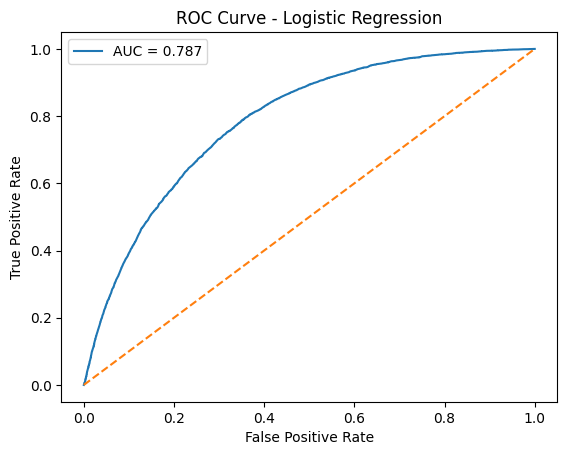

In [8]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import os

save_path = "../4_evaluation_and_paper/"
os.makedirs(save_path, exist_ok=True)

fpr, tpr, _ = roc_curve(y_test, y_proba_lr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {lr_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()

plt.savefig(save_path + "logistic_regression_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

2. RANDOM FOREST 

A. Defines the Random Forest model with fixed randomness for repeatable results

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import os

rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

threshold = 0.45
y_pred_rf = (y_proba_rf >= threshold).astype(int)

B. Trains the Random Forest model on the centralized training data

C. Generates class predictions and probability scores for evaluation and ROC analysis.

In [10]:
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

D. Checks baseline accuracy and detailed class-wise performance

In [11]:
from sklearn.metrics import accuracy_score, classification_report

rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", rf_accuracy)

print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7188724780384207
              precision    recall  f1-score   support

           0       0.92      0.73      0.82     44185
           1       0.29      0.63      0.40      7610

    accuracy                           0.72     51795
   macro avg       0.61      0.68      0.61     51795
weighted avg       0.83      0.72      0.76     51795



E. Shows how many predictions are correct and wrong for each class.

In [12]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)

[[32432 11753]
 [ 2808  4802]]


F. Measures how well Random Forest separates diabetic vs non-diabetic cases.

In [13]:
from sklearn.metrics import roc_auc_score

rf_auc = roc_auc_score(y_test, y_proba_rf)
print("Random Forest ROC-AUC:", rf_auc)

Random Forest ROC-AUC: 0.7431684395900227


G. Plots the ROC curve for Random Forest and saves it for evaluation/paper use

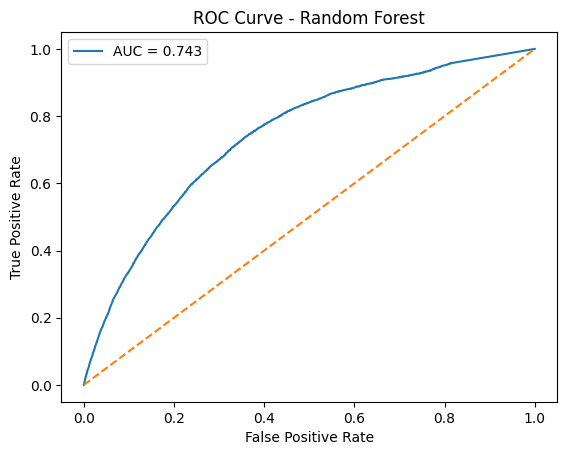

In [14]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import os

save_path = "../4_evaluation_and_paper/"
os.makedirs(save_path, exist_ok=True)

fpr, tpr, _ = roc_curve(y_test, y_proba_rf)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {rf_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()

plt.savefig(save_path + "random_forest_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

3. XGBOOST

In [15]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

A. Defines the XGBoost model with controlled randomness for repeatable runs

In [16]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
    use_label_encoder=False
)

B. Trains the XGBoost model on the centralized training dataset.

In [17]:
xgb_model.fit(X_train, y_train)

D:\Python lang\Lib\site-packages\xgboost\training.py:183: UserWarning: [21:36:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


C. Generates predictions and probability scores for evaluation.

In [18]:
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [19]:
from sklearn.metrics import confusion_matrix

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print(cm_xgb)

[[30292 13893]
 [ 1748  5862]]


F. Measures how well XGBoost separates diabetic vs non-diabetic cases.

In [20]:
from sklearn.metrics import roc_auc_score

xgb_auc = roc_auc_score(y_test, y_proba_xgb)
print("XGBoost ROC-AUC:", xgb_auc)

XGBoost ROC-AUC: 0.8039716833877153


G. Plots the ROC curve for XGBoost and saves it to the evaluation folder.

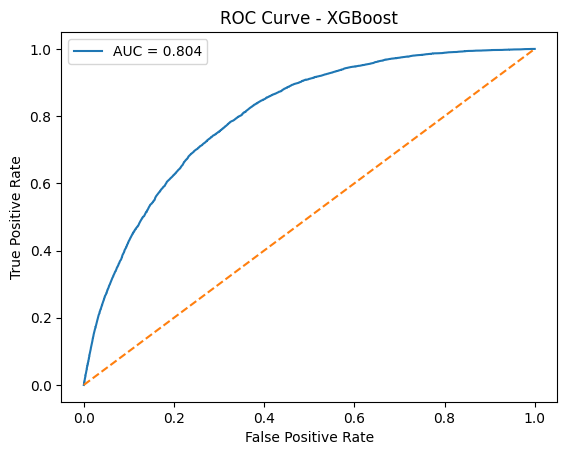

In [21]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import os

save_path = "../4_evaluation_and_paper/"
os.makedirs(save_path, exist_ok=True)

fpr, tpr, _ = roc_curve(y_test, y_proba_xgb)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {xgb_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()

plt.savefig(save_path + "xgboost_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

4. BUILD VOTING

A. Defines a soft voting classifier

In [22]:
from sklearn.ensemble import VotingClassifier
voting_model = VotingClassifier(
    estimators=[
        ("lr", lr_model),
        ("rf", rf_model),
        ("xgb", xgb_model)
    ],
    voting="soft",
    weights=[1, 1, 2],   # Give XGBoost more weight
    n_jobs=-1
)

B. Trains the soft voting 

In [23]:
voting_model.fit(X_train, y_train)

,estimators,"[('lr', ...), ('rf', ...), ...]"
,voting,'soft'
,weights,"[1, 1, ...]"
,n_jobs,-1
,flatten_transform,True
,verbose,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True


C. Generates final class predictions and probability scores for evaluation

In [24]:
y_proba_vote = voting_model.predict_proba(X_test)[:, 1]
y_pred_vote = (y_proba_vote >= 0.5).astype(int)

D. Evaluates overall accuracy

In [25]:
from sklearn.metrics import accuracy_score, classification_report

vote_accuracy = accuracy_score(y_test, y_pred_vote)
print("Voting Accuracy:", vote_accuracy)

print(classification_report(y_test, y_pred_vote))

Voting Accuracy: 0.7158219905396274
              precision    recall  f1-score   support

           0       0.94      0.71      0.81     44185
           1       0.31      0.74      0.43      7610

    accuracy                           0.72     51795
   macro avg       0.62      0.73      0.62     51795
weighted avg       0.85      0.72      0.76     51795



E. Shows how many healthy and diabetic cases were correctly and incorrectly predicted

In [26]:
from sklearn.metrics import confusion_matrix

cm_vote = confusion_matrix(y_test, y_pred_vote)
print("Confusion Matrix:\n", cm_vote)

Confusion Matrix:
 [[31430 12755]
 [ 1964  5646]]


F.  Measures how well the ensemble separates diabetic vs non-diabetic cases.

In [27]:
from sklearn.metrics import roc_auc_score

vote_auc = roc_auc_score(y_test, y_proba_vote)
print("Voting ROC-AUC:", vote_auc)

Voting ROC-AUC: 0.7988866798702207


G. Plots the ROC curve

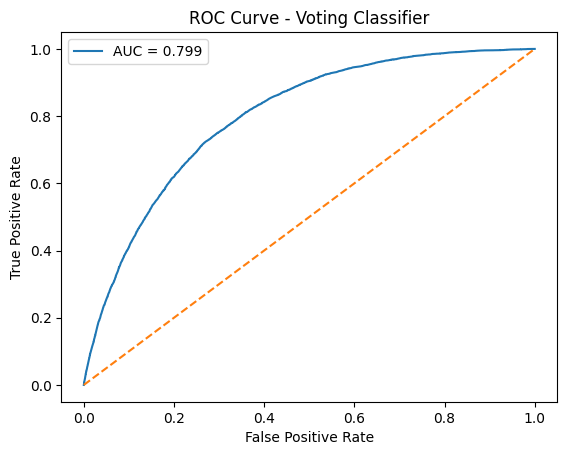

In [28]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import os

save_path = "../4_evaluation_and_paper/"
os.makedirs(save_path, exist_ok=True)

fpr, tpr, _ = roc_curve(y_test, y_proba_vote)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {vote_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Voting Classifier")
plt.legend()

plt.savefig(save_path + "voting_classifier_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [29]:
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score

accuracy_list = []
auc_list = []
recall_list = []
f1_list = []

sss = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

for train_idx, test_idx in sss.split(X, y):
    
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    
    model = XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=None
    )
    
    model.fit(X_train, y_train)
    
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= 0.5).astype(int)
    
    

In [30]:
accuracy_list.append(accuracy_score(y_test, y_pred))
auc_list.append(roc_auc_score(y_test, y_proba))
recall_list.append(recall_score(y_test, y_pred))
f1_list.append(f1_score(y_test, y_pred))

print("Accuracy: {:.3f} ± {:.3f}".format(np.mean(accuracy_list), np.std(accuracy_list)))
print("ROC-AUC: {:.3f} ± {:.3f}".format(np.mean(auc_list), np.std(auc_list)))
print("Recall: {:.3f} ± {:.3f}".format(np.mean(recall_list), np.std(recall_list)))
print("F1-score: {:.3f} ± {:.3f}".format(np.mean(f1_list), np.std(f1_list)))

Accuracy: 0.696 ± 0.000
ROC-AUC: 0.804 ± 0.000
Recall: 0.777 ± 0.000
F1-score: 0.429 ± 0.000


Unified Plots

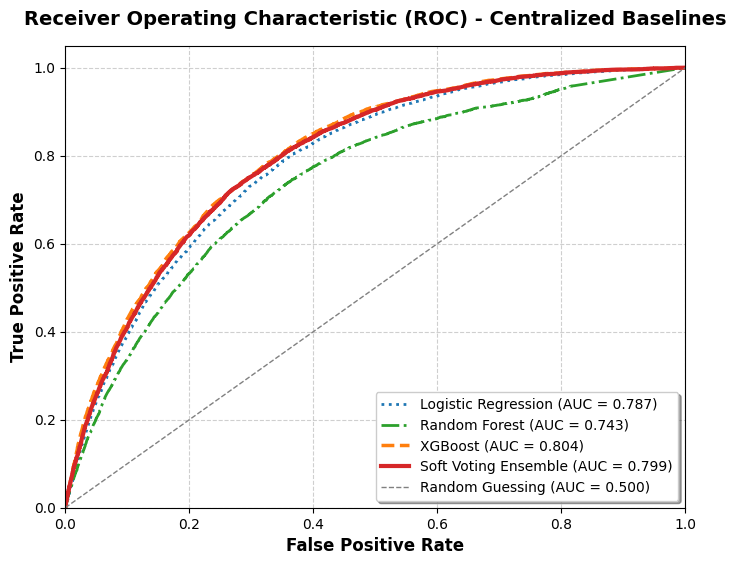

In [31]:
# reconstructed pristine X_test & y_test to prevent CV loop bleed
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Recalculate probabilities strictly on the true test set
fresh_proba_lr = lr_model.predict_proba(X_test)[:, 1]
fresh_proba_rf = rf_model.predict_proba(X_test)[:, 1]
fresh_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
fresh_proba_vote = voting_model.predict_proba(X_test)[:, 1]

# Get fresh auc scores
fresh_auc_lr = roc_auc_score(y_test, fresh_proba_lr)
fresh_auc_rf = roc_auc_score(y_test, fresh_proba_rf)
fresh_auc_xgb = roc_auc_score(y_test, fresh_proba_xgb)
fresh_auc_vote = roc_auc_score(y_test, fresh_proba_vote)

fpr_lr, tpr_lr, _ = roc_curve(y_test, fresh_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, fresh_proba_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, fresh_proba_xgb)
fpr_vote, tpr_vote, _ = roc_curve(y_test, fresh_proba_vote)

plt.figure(figsize=(8, 6))
plt.style.use("default")

plt.plot(fpr_lr, tpr_lr, color="#1f77b4", linestyle=":", linewidth=2, label=f"Logistic Regression (AUC = {fresh_auc_lr:.3f})")
plt.plot(fpr_rf, tpr_rf, color="#2ca02c", linestyle="-.", linewidth=2, label=f"Random Forest (AUC = {fresh_auc_rf:.3f})")
plt.plot(fpr_xgb, tpr_xgb, color="#ff7f0e", linestyle="--", linewidth=2.5, label=f"XGBoost (AUC = {fresh_auc_xgb:.3f})")
plt.plot(fpr_vote, tpr_vote, color="#d62728", linestyle="-", linewidth=3, label=f"Soft Voting Ensemble (AUC = {fresh_auc_vote:.3f})")

plt.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1, label="Random Guessing (AUC = 0.500)")

plt.title("Receiver Operating Characteristic (ROC) - Centralized Baselines", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("False Positive Rate", fontsize=12, fontweight="bold")
plt.ylabel("True Positive Rate", fontsize=12, fontweight="bold")
plt.legend(loc="lower right", fontsize=10, frameon=True, shadow=True)
plt.grid(True, linestyle="--", alpha=0.6)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

save_path_pdf = "../4_evaluation_and_paper/plots/unified_roc_curve.pdf"
save_path_png = "../4_evaluation_and_paper/plots/unified_roc_curve.png"

plt.savefig(save_path_pdf, format="pdf", dpi=300, bbox_inches="tight")
plt.savefig(save_path_png, format="png", dpi=300, bbox_inches="tight")

plt.show()
